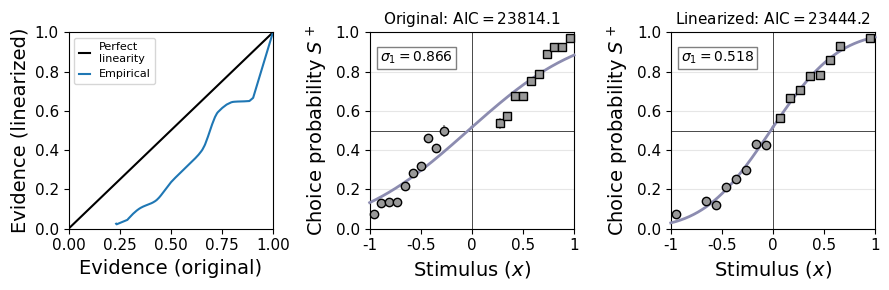

In [1]:
import pandas as pd
import numpy as np
import remeta
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('error')


d = pd.read_csv(f'data_Maniscalco_2017_expt2.csv')
d = d[~d.Response.isna()].reset_index(drop=True)

choices = d.Response.astype(int).values
stimulus_ids = np.sign(d.Stimulus.values - 0.5).astype(int)
difficulty_levels = d.Contrast.values
remeta.check_linearity(stimulus_ids, choices, difficulty_levels)
plt.savefig('../content/img/linearization_example.png', bbox_inches='tight', pad_inches=0.02)

In [2]:
stimuli_linear = remeta.linearize_stimulus_evidence(stimulus_ids, choices, difficulty_levels)

Before: type1_noise = 0.8662, AIC = 23814.1
After: type1_noise = 0.6754, AIC = 23445.1
	-> Linearization improves the model fit.


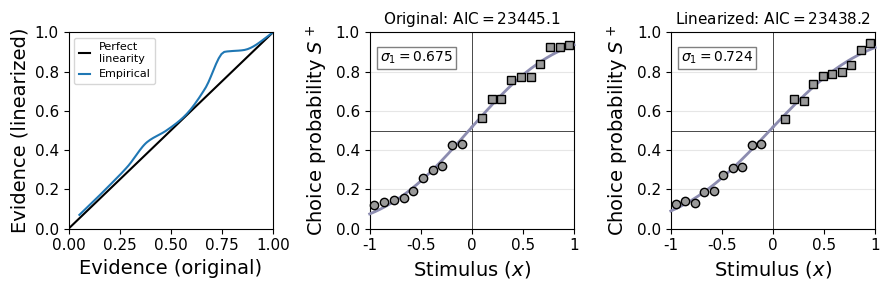

In [3]:
remeta.check_linearity(stimuli_linear, choices)

Samples per difficulty level:
	Level 1 [Center 0.02554]: 238 samples
	Level 2 [Center 0.03059]: 1693 samples
	Level 3 [Center 0.03564]: 2852 samples
	Level 4 [Center 0.0407]: 1801 samples
	Level 5 [Center 0.04575]: 1661 samples
	Level 6 [Center 0.0508]: 2402 samples
	Level 7 [Center 0.05585]: 1597 samples
	Level 8 [Center 0.06091]: 1869 samples
	Level 9 [Center 0.06596]: 2307 samples
	Level 10 [Center 0.07101]: 1360 samples
	Level 11 [Center 0.07606]: 850 samples
	Level 12 [Center 0.08112]: 952 samples
	Level 13 [Center 0.08617]: 679 samples
	Level 14 [Center 0.09122]: 340 samples
	Level 15 [Center 0.09628]: 272 samples
Before: type1_noise = 0.8662, AIC = 23814.1
After: type1_noise = 0.5592, AIC = 23437.2
	-> Linearization improves the model fit.


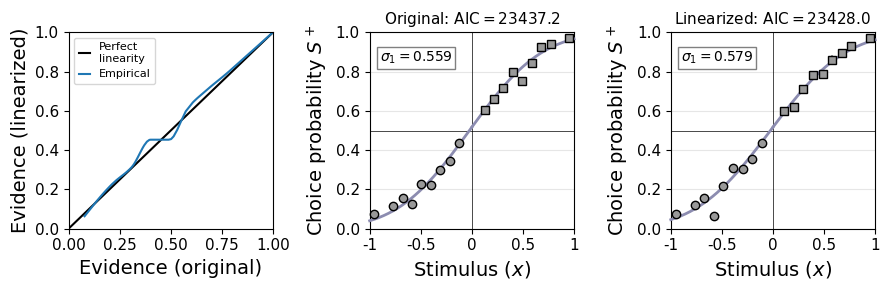

In [7]:
stimuli_linear3 = remeta.linearize_stimulus_evidence(stimulus_ids, choices, difficulty_levels, method='discretize_linear', discretize_nlevels=15)
remeta.check_linearity(stimuli_linear3, choices)
width, height = plt.gcf().get_size_inches()
from matplotlib.transforms import Bbox
bbox = Bbox.from_bounds(0, 0, width * 0.66, height)
plt.savefig('../content/img/linearization_example_after.png', bbox_inches=bbox, pad_inches=0.02)